### UnlabeledLogReg implementation

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogReg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
)
from src.data_generation import apply_mcar, apply_mar1, apply_mar2, apply_mnar
from src.fista import FistaLogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
# Load all datasets
datasets = {}

dataset_info = {
    'Madelon': 'data/madelon/madelon_processed.csv',
    'Car Eval': 'data/car_eval/car_eval_processed.csv',
    'Speed Dating': 'data/speed_dating/speed_dating_processed.csv',
    'Student Performance': 'data/stud_perf/students_processed.csv'
}

for name, path in dataset_info.items():
    try:
        data = pd.read_csv(path)
        datasets[name] = data
        print(f"{name:25} - Shape: {data.shape}")
    except FileNotFoundError:
        print(f"{name:25} - File not found: {path}")


Madelon                   - Shape: (2600, 501)
Car Eval                  - Shape: (1728, 16)
Speed Dating              - Shape: (8378, 330)
Student Performance       - Shape: (395, 27)


In [19]:
def prepare_dataset(data, test_size_1=0.4, test_size_2=0.5, random_state=42):
    """
    Prepare a dataset: extract features and labels, split into train/valid/test,
    standardize features, and convert labels to binary.
    """
    X = data.drop(columns=['Y']).values
    y = data['Y'].values
    
    # Train-validation-test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size_1, random_state=random_state
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size_2, random_state=random_state
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to binary labels
    y_train_binary = (y_train > 0.5).astype(int)
    y_valid_binary = (y_valid > 0.5).astype(int)
    y_test_binary = (y_test > 0.5).astype(int)
    
    return {
        'X_train': X_train_scaled,
        'X_valid': X_valid_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_binary,
        'y_valid': y_valid_binary,
        'y_test': y_test_binary
    }

# Prepare all datasets
prepared_datasets = {}
print("Preparing datasets...\n")

for name, data in datasets.items():
    prepared_datasets[name] = prepare_dataset(data)
    print(f"{name:25} - Train: {prepared_datasets[name]['X_train'].shape}, "
          f"Valid: {prepared_datasets[name]['X_valid'].shape}, "
          f"Test: {prepared_datasets[name]['X_test'].shape}")


Preparing datasets...

Madelon                   - Train: (1560, 500), Valid: (520, 500), Test: (520, 500)
Car Eval                  - Train: (1036, 15), Valid: (346, 15), Test: (346, 15)
Speed Dating              - Train: (5026, 329), Valid: (1676, 329), Test: (1676, 329)
Student Performance       - Train: (237, 26), Valid: (79, 26), Test: (79, 26)


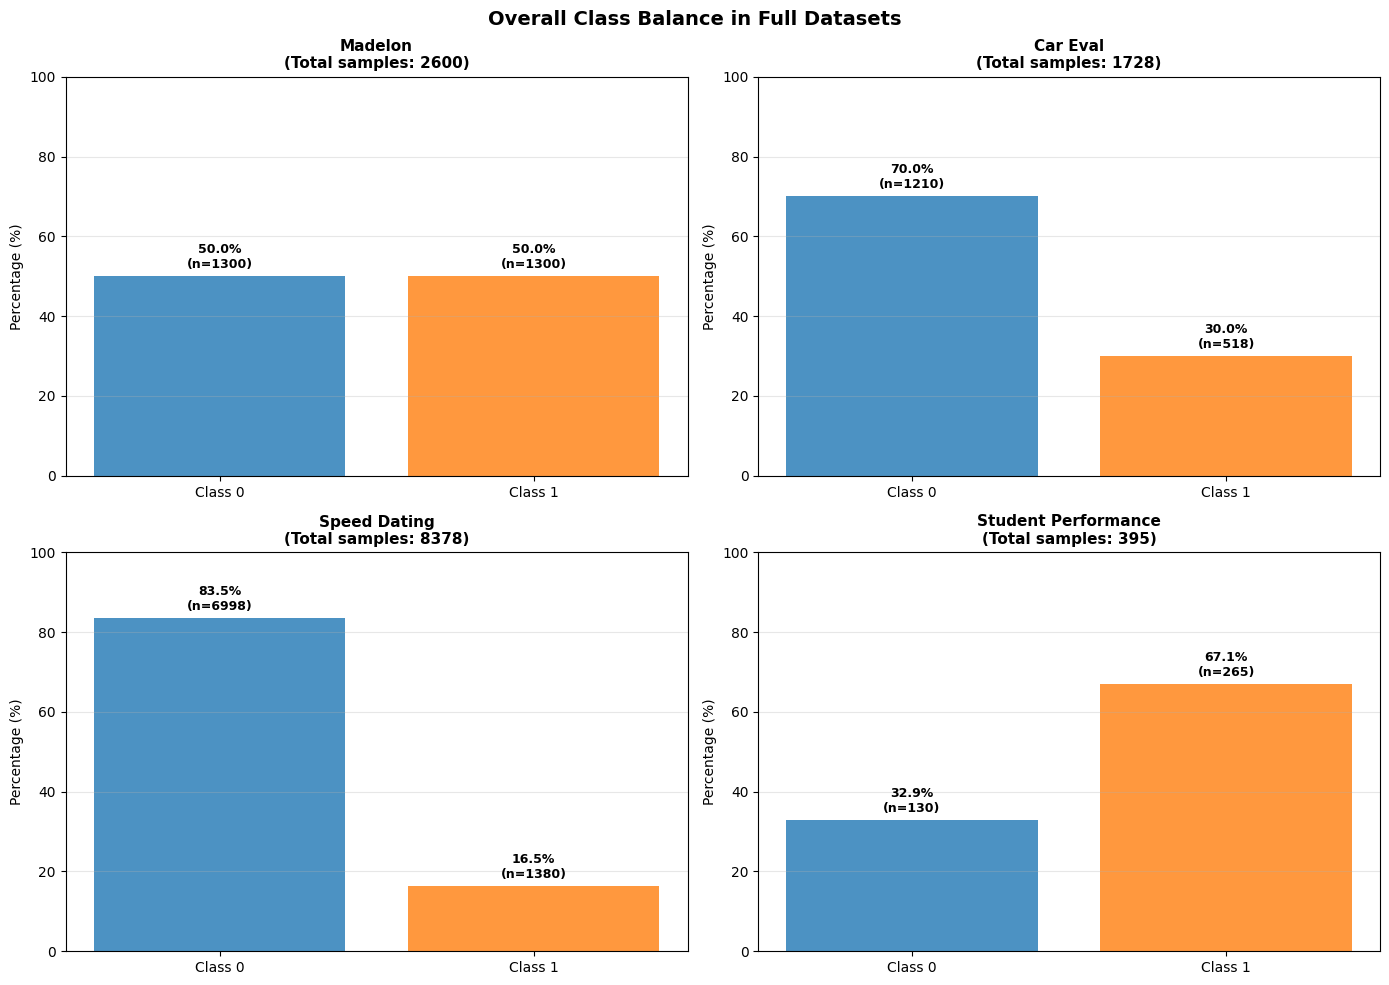

OVERALL CLASS BALANCE SUMMARY

Madelon:
  Total samples: 2600
  Class 0: 1300 (50.00%)
  Class 1: 1300 (50.00%)

Car Eval:
  Total samples: 1728
  Class 0: 1210 (70.02%)
  Class 1: 518 (29.98%)

Speed Dating:
  Total samples: 8378
  Class 0: 6998 (83.53%)
  Class 1: 1380 (16.47%)

Student Performance:
  Total samples: 395
  Class 0: 130 (32.91%)
  Class 1: 265 (67.09%)


In [57]:
# Analyze class balance for whole datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dataset_name, data) in enumerate(datasets.items()):
    y = data['Y'].values
    
    ax = axes[idx]
    
    # Calculate class distribution
    counts = np.bincount(y.astype(int))
    pct = counts / len(y) * 100
    
    # Create bar plot
    ax.bar(['Class 0', 'Class 1'], pct, alpha=0.8, color=['#1f77b4', '#ff7f0e'])
    
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.set_title(f'{dataset_name}\n(Total samples: {len(y)})', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add percentage labels on bars
    for i, (count, p) in enumerate(zip(counts, pct)):
        ax.text(i, p + 2, f'{p:.1f}%\n(n={count})', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Overall Class Balance in Full Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("OVERALL CLASS BALANCE SUMMARY")
print("="*80)
for dataset_name, data in datasets.items():
    y = data['Y'].values
    counts = np.bincount(y.astype(int))
    pct = counts / len(y) * 100
    print(f"\n{dataset_name}:")
    print(f"  Total samples: {len(y)}")
    print(f"  Class 0: {counts[0]} ({pct[0]:.2f}%)")
    print(f"  Class 1: {counts[1]} ({pct[1]:.2f}%)")

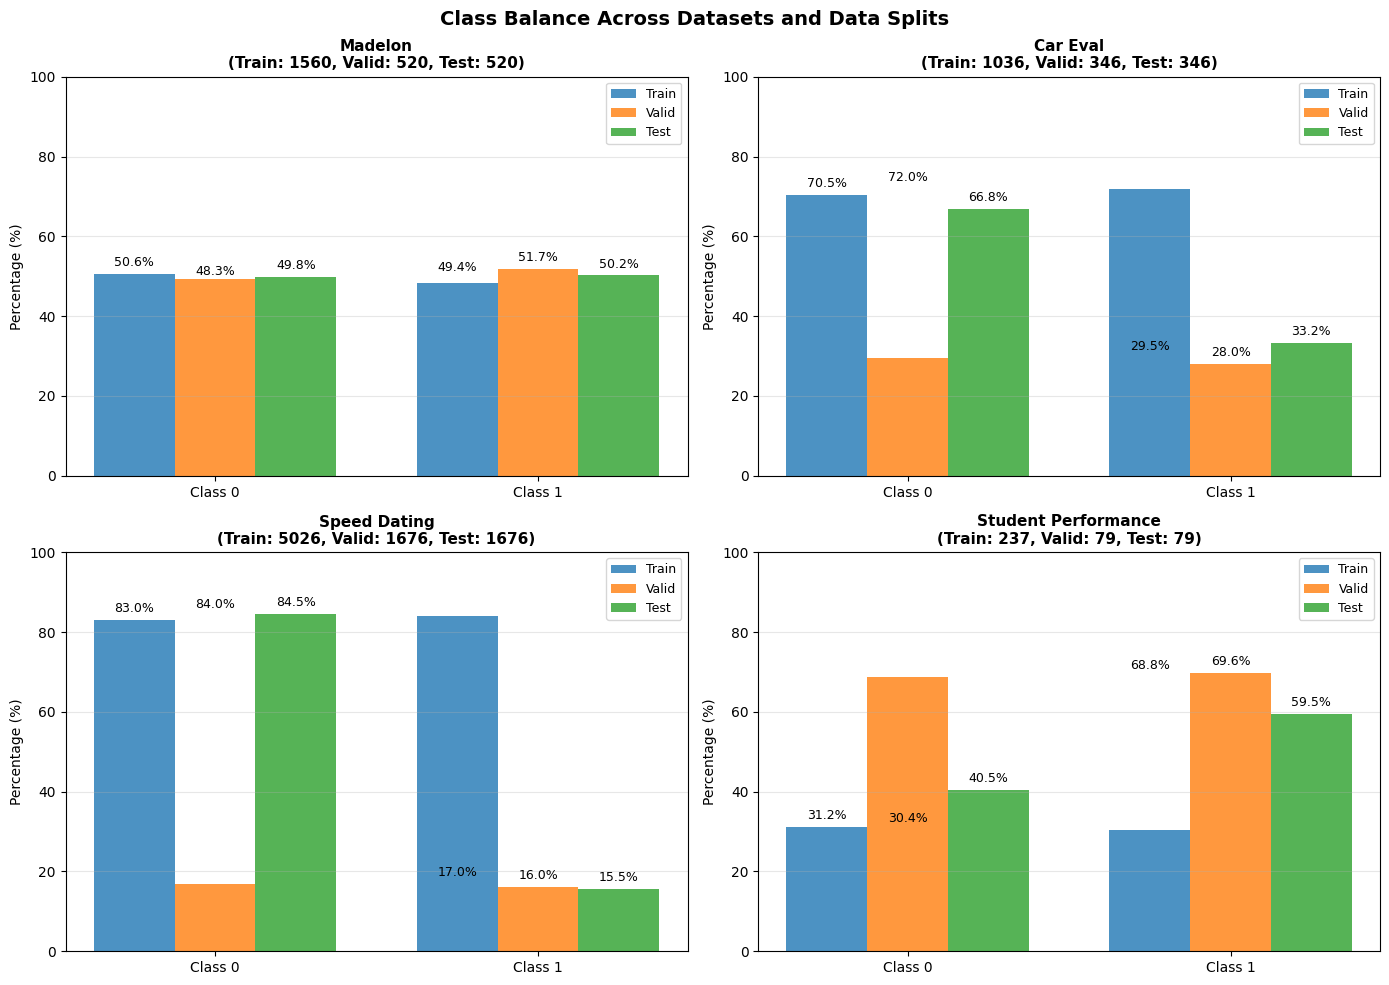


CLASS BALANCE SUMMARY

Madelon:
  Train - Class 0: 790, Class 1: 770
  Valid - Class 0: 251, Class 1: 269
  Test  - Class 0: 259, Class 1: 261

Car Eval:
  Train - Class 0: 730, Class 1: 306
  Valid - Class 0: 249, Class 1: 97
  Test  - Class 0: 231, Class 1: 115

Speed Dating:
  Train - Class 0: 4174, Class 1: 852
  Valid - Class 0: 1408, Class 1: 268
  Test  - Class 0: 1416, Class 1: 260

Student Performance:
  Train - Class 0: 74, Class 1: 163
  Valid - Class 0: 24, Class 1: 55
  Test  - Class 0: 32, Class 1: 47


In [56]:
# Analyze class balance for each dataset
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dataset_name, data_splits) in enumerate(prepared_datasets.items()):
    y_train = data_splits['y_train']
    y_valid = data_splits['y_valid']
    y_test = data_splits['y_test']
    
    ax = axes[idx]
    
    # Calculate class distribution
    train_counts = np.bincount(y_train)
    valid_counts = np.bincount(y_valid)
    test_counts = np.bincount(y_test)
    
    train_pct = train_counts / len(y_train) * 100
    valid_pct = valid_counts / len(y_valid) * 100
    test_pct = test_counts / len(y_test) * 100
    
    
    x = np.arange(2)
    width = 0.25
    
    ax.bar(x - width, [train_pct[0], valid_pct[0]], width, label='Train', alpha=0.8)
    ax.bar(x, [train_pct[1], valid_pct[1]], width, label='Valid', alpha=0.8)
    ax.bar(x + width, [test_pct[0], test_pct[1]], width, label='Test', alpha=0.8)
    
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.set_title(f'{dataset_name}\n(Train: {len(y_train)}, Valid: {len(y_valid)}, Test: {len(y_test)})', 
                 fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 100])
    
    
    for i, (t0, t1, v0, v1, ts0, ts1) in enumerate(zip(train_pct[0:1], train_pct[1:2], 
                                                         valid_pct[0:1], valid_pct[1:2],
                                                         test_pct[0:1], test_pct[1:2])):
        if i == 0:
            ax.text(-width, t0 + 2, f'{t0:.1f}%', ha='center', fontsize=9)
            ax.text(0, v0 + 2, f'{v0:.1f}%', ha='center', fontsize=9)
            ax.text(width, ts0 + 2, f'{ts0:.1f}%', ha='center', fontsize=9)
            ax.text(1 - width, t1 + 2, f'{t1:.1f}%', ha='center', fontsize=9)
            ax.text(1, v1 + 2, f'{v1:.1f}%', ha='center', fontsize=9)
            ax.text(1 + width, ts1 + 2, f'{ts1:.1f}%', ha='center', fontsize=9)

plt.suptitle('Class Balance Across Datasets and Data Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "="*80)
print("CLASS BALANCE SUMMARY")
print("="*80)
for dataset_name, data_splits in prepared_datasets.items():
    print(f"\n{dataset_name}:")
    print(f"  Train - Class 0: {np.sum(data_splits['y_train']==0)}, Class 1: {np.sum(data_splits['y_train']==1)}")
    print(f"  Valid - Class 0: {np.sum(data_splits['y_valid']==0)}, Class 1: {np.sum(data_splits['y_valid']==1)}")
    print(f"  Test  - Class 0: {np.sum(data_splits['y_test']==0)}, Class 1: {np.sum(data_splits['y_test']==1)}")

### Two different methods of imputation:
* kNN (kNearestNeighbors)
* training LogisticRegression from sklearn on labeled data and getting labels for missing data from those previous ones

In [36]:
class UnlabeledLogReg:
    def __init__(self, X_valid, y_valid, imputation_method='knn', fista_max_iter=1000):
        self.imputation_method = imputation_method
        self.final_model = FistaLogisticRegression(
            max_iter=fista_max_iter,
            X_valid=X_valid,
            y_valid=y_valid
        )
        X_valid = X_valid
        y_valid = y_valid

    def fit(self, X, y_obs):
        labeled_mask = (y_obs != -1)
        unlabeled_mask = (y_obs == -1)

        if not np.any(unlabeled_mask): # For Oracle and Naive cases
            y_complete = y_obs.copy()
        else:
            if self.imputation_method == 'knn':
                imputer = KNeighborsClassifier(n_neighbors=5)
            elif self.imputation_method == 'logreg':
                imputer = SklearnLogReg(max_iter=1000)
            else:
                raise ValueError("Invalid imputation method. Choose eitehr knn or logreg")
            
            imputer.fit(X[labeled_mask], y_obs[labeled_mask])
            guessed_labels = imputer.predict(X[unlabeled_mask])
            y_complete = y_obs.copy()
            y_complete[unlabeled_mask] = guessed_labels

        self.final_model.fit(X, y_complete)

    def predict_proba(self, X):
            return self.final_model.predict_proba(X)
    
    def predict(self, X):
        probs = self.predict_proba(X)
        # Extract class 1 probabilities if probs is 2D array (n_samples >= 2)
        if probs.ndim == 2:
            probs = probs[:, 1]
        return (probs > 0.5).astype(int)

In [37]:
def evaluate_model(model, X_test, y_test):
    # Raw predictions (0 lub 1)
    y_pred = model.predict(X_test)
    # Probabilites for ROC AUC
    y_prob = model.predict_proba(X_test)
    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]
        
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }

# Main experiment
* For every dataset we will check every 4 Y-missing data generation scheme:
    * MCAR
    * MAR1
    * MAR2
    * MNAR

For every of those scenarios we train:
* Oracle: FIST on original, fully labeled training data
* Naive: FISTA only on y_train_obs, where there is no -1
* UnlabeledLogReg (with KNN)
* UnlabeledLogReg (With LogisticRegression from sklearn)

Important: in our experiments, missing data affects only the training set.

In [49]:
all_experiment_results = {}
mechanisms = ['MCAR', 'MAR1', 'MAR2', 'MNAR']

for dataset_name, data_splits in prepared_datasets.items():
    X_tr = data_splits['X_train']
    y_tr_true = data_splits['y_train']  
    X_ts = data_splits['X_test']
    y_ts = data_splits['y_test']        
    
    X_val = data_splits['X_valid']
    y_val = data_splits['y_valid']
    
    results_list = []
    
    for mech in mechanisms:
        if mech == 'MCAR':
            y_tr_obs = apply_mcar(X_tr, y_tr_true, c=0.4) 
        elif mech == 'MAR1':
            y_tr_obs = apply_mar1(X_tr, y_tr_true, feature_idx=0)
        elif mech == 'MAR2':
            y_tr_obs = apply_mar2(X_tr, y_tr_true)
        elif mech == 'MNAR':
            y_tr_obs = apply_mnar(X_tr, y_tr_true)

        oracle_model = FistaLogisticRegression(max_iter=1000, X_valid=X_val, y_valid=y_val)
        oracle_model.fit(X_tr, y_tr_true)
        res_oracle = evaluate_model(oracle_model, X_ts, y_ts)
        res_oracle.update({'Mechanism': mech, 'Method': 'Oracle'})
        results_list.append(res_oracle)
        
        valid_mask = (y_tr_obs != -1)
        naive_model = FistaLogisticRegression(max_iter=500, X_valid=X_val, y_valid=y_val)
        naive_model.fit(X_tr[valid_mask], y_tr_obs[valid_mask])
        res_naive = evaluate_model(naive_model, X_ts, y_ts)
        res_naive.update({'Mechanism': mech, 'Method': 'Naive'})
        results_list.append(res_naive)
        
        unlabeled_knn = UnlabeledLogReg(fista_max_iter=1000, X_valid=X_val, y_valid=y_val, imputation_method='knn')
        unlabeled_knn.fit(X_tr, y_tr_obs)
        res_unlabeled_knn = evaluate_model(unlabeled_knn, X_ts, y_ts)
        res_unlabeled_knn.update({'Mechanism': mech, 'Method': 'Unlabeled (KNN)'})
        results_list.append(res_unlabeled_knn)
        
        unlabeled_logreg = UnlabeledLogReg(fista_max_iter=1000, X_valid=X_val, y_valid=y_val, imputation_method='logreg')
        unlabeled_logreg.fit(X_tr, y_tr_obs)
        res_unlabeled_logreg = evaluate_model(unlabeled_logreg, X_ts, y_ts)
        res_unlabeled_logreg.update({'Mechanism': mech, 'Method': 'Unlabeled (LogReg)'})
        results_list.append(res_unlabeled_logreg)

    df_results = pd.DataFrame(results_list)
    cols = ['Mechanism', 'Method', 'Accuracy', 'Balanced Accuracy', 'F1-Score', 'ROC AUC']
    all_experiment_results[dataset_name] = df_results[cols]


In [50]:
for dataset_name, df in all_experiment_results.items():
    print(f"Results for: {dataset_name}")
    display(df.round(4))

Results for: Madelon


,Mechanism,Method,Accuracy,Balanced Accuracy,F1-Score,ROC AUC
0,MCAR,Oracle,0.5769,0.5769,0.5802,0.6023
1,MCAR,Naive,0.5769,0.5769,0.5785,0.5957
2,MCAR,Unlabeled (KNN),0.5019,0.5000,0.6675,0.5968
3,MCAR,Unlabeled (LogReg),0.5769,0.5766,0.6099,0.5950
4,MAR1,Oracle,0.5769,0.5769,0.5802,0.6023
5,MAR1,Naive,0.5885,0.5884,0.5916,0.6001
6,MAR1,Unlabeled (KNN),0.5692,0.5689,0.6028,0.5960
7,MAR1,Unlabeled (LogReg),0.5788,0.5785,0.6151,0.5950
8,MAR2,Oracle,0.5769,0.5769,0.5802,0.6023
9,MAR2,Naive,0.5654,0.5654,0.5654,0.5909


Results for: Car Eval


,Mechanism,Method,Accuracy,Balanced Accuracy,F1-Score,ROC AUC
0,MCAR,Oracle,0.9566,0.9544,0.9356,0.9928
1,MCAR,Naive,0.9595,0.9610,0.9407,0.9910
2,MCAR,Unlabeled (KNN),0.9451,0.9349,0.9163,0.9898
3,MCAR,Unlabeled (LogReg),0.9624,0.9631,0.9447,0.9914
4,MAR1,Oracle,0.9566,0.9544,0.9356,0.9928
5,MAR1,Naive,0.9451,0.9349,0.9163,0.9891
6,MAR1,Unlabeled (KNN),0.9104,0.8783,0.8531,0.9781
7,MAR1,Unlabeled (LogReg),0.9451,0.9370,0.9170,0.9898
8,MAR2,Oracle,0.9566,0.9544,0.9356,0.9928
9,MAR2,Naive,0.9422,0.9327,0.9123,0.9918


Results for: Speed Dating


,Mechanism,Method,Accuracy,Balanced Accuracy,F1-Score,ROC AUC
0,MCAR,Oracle,0.8479,0.6227,0.3765,0.8197
1,MCAR,Naive,0.8586,0.6007,0.3324,0.8280
2,MCAR,Unlabeled (KNN),0.8461,0.5148,0.0652,0.8260
3,MCAR,Unlabeled (LogReg),0.8580,0.6067,0.3462,0.8274
4,MAR1,Oracle,0.8479,0.6227,0.3765,0.8197
5,MAR1,Naive,0.8538,0.5618,0.2271,0.8274
6,MAR1,Unlabeled (KNN),0.8425,0.5049,0.0294,0.8102
7,MAR1,Unlabeled (LogReg),0.8526,0.5658,0.2400,0.8266
8,MAR2,Oracle,0.8479,0.6227,0.3765,0.8197
9,MAR2,Naive,0.8538,0.5948,0.3175,0.8326


Results for: Student Performance


,Mechanism,Method,Accuracy,Balanced Accuracy,F1-Score,ROC AUC
0,MCAR,Oracle,0.6582,0.5831,0.7731,0.7613
1,MCAR,Naive,0.5949,0.5000,0.7460,0.6782
2,MCAR,Unlabeled (KNN),0.6329,0.5519,0.7603,0.6782
3,MCAR,Unlabeled (LogReg),0.5949,0.5000,0.7460,0.6782
4,MAR1,Oracle,0.6582,0.5831,0.7731,0.7613
5,MAR1,Naive,0.5949,0.5000,0.7460,0.6782
6,MAR1,Unlabeled (KNN),0.5949,0.5000,0.7460,0.6782
7,MAR1,Unlabeled (LogReg),0.6456,0.5675,0.7667,0.7563
8,MAR2,Oracle,0.6582,0.5831,0.7731,0.7613
9,MAR2,Naive,0.5949,0.5000,0.7460,0.6715


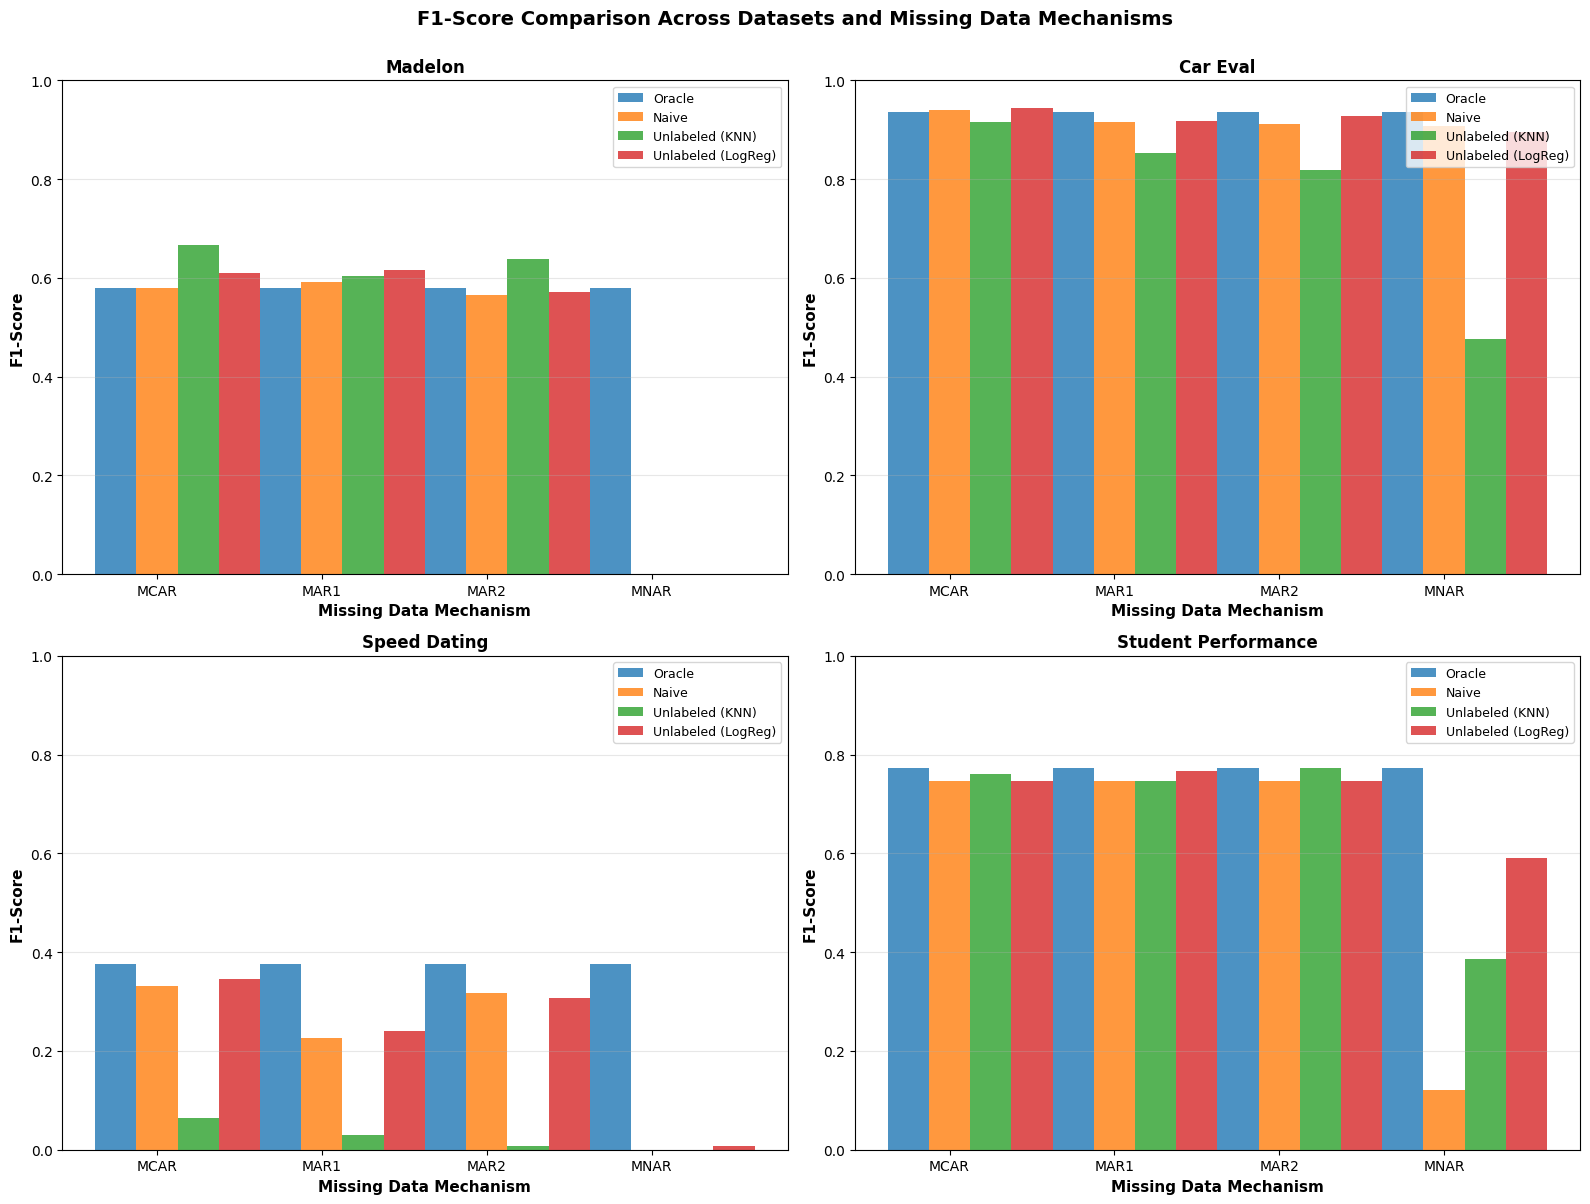

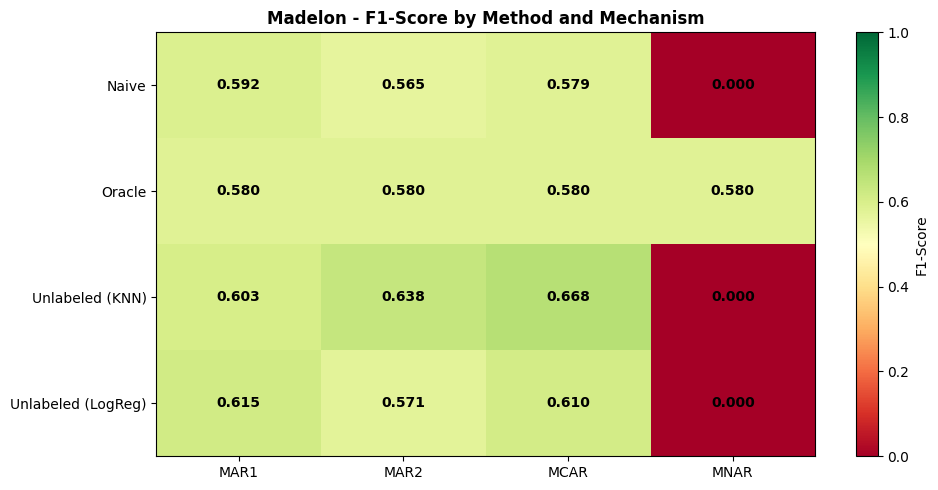

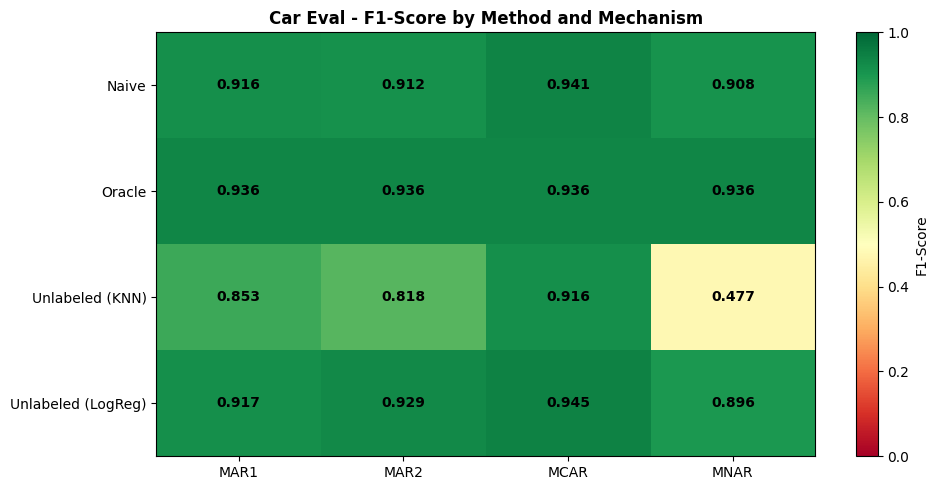

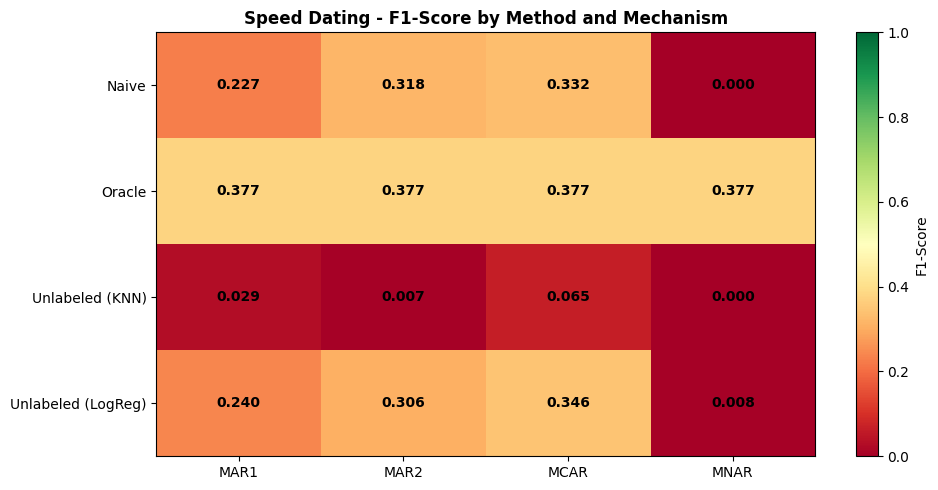

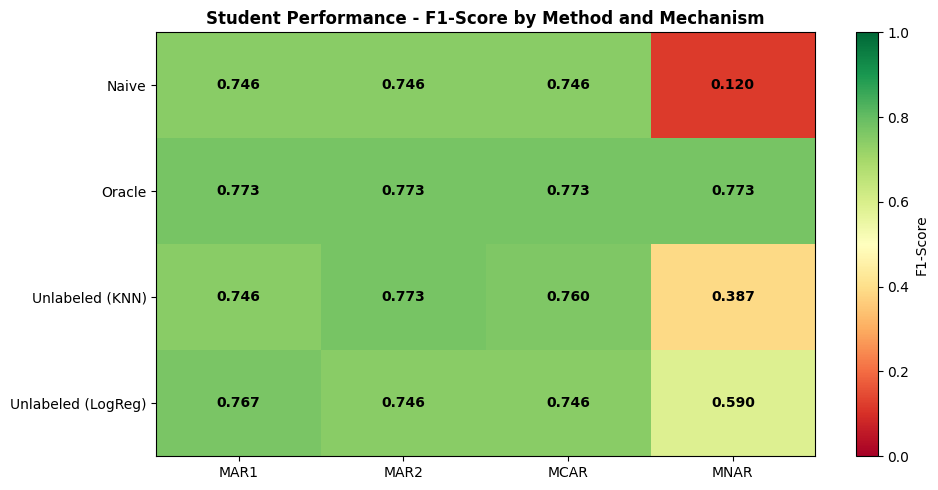

In [51]:
# Create a summary visualization of all experiment results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (dataset_name, df_results) in enumerate(all_experiment_results.items()):
    ax = axes[idx]
    
    # Prepare data for plotting
    methods = df_results['Method'].unique()
    mechanisms = df_results['Mechanism'].unique()
    
    x = np.arange(len(mechanisms))
    width = 0.25
    
    for i, method in enumerate(methods):
        f1_scores = [df_results[(df_results['Mechanism'] == mech) & (df_results['Method'] == method)]['F1-Score'].values[0] 
                     for mech in mechanisms]
        ax.bar(x + i*width, f1_scores, width, label=method, alpha=0.8)
    
    ax.set_xlabel('Missing Data Mechanism', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name}', fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(mechanisms)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])

plt.suptitle('F1-Score Comparison Across Datasets and Missing Data Mechanisms', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Create a heatmap summary for each dataset
for dataset_name, df_results in all_experiment_results.items():
    # Pivot for F1-Score heatmap
    pivot_f1 = df_results.pivot_table(values='F1-Score', index='Method', columns='Mechanism')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(pivot_f1.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(len(pivot_f1.columns)))
    ax.set_yticks(np.arange(len(pivot_f1.index)))
    ax.set_xticklabels(pivot_f1.columns)
    ax.set_yticklabels(pivot_f1.index)
    
    # Add text annotations
    for i in range(len(pivot_f1.index)):
        for j in range(len(pivot_f1.columns)):
            text = ax.text(j, i, f'{pivot_f1.values[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title(f'{dataset_name} - F1-Score by Method and Mechanism', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='F1-Score')
    plt.tight_layout()
    plt.show()

Analyzing parameter 'c' for dataset: Madelon...
Analyzing parameter 'c' for dataset: Car Eval...
Analyzing parameter 'c' for dataset: Speed Dating...
Analyzing parameter 'c' for dataset: Student Performance...


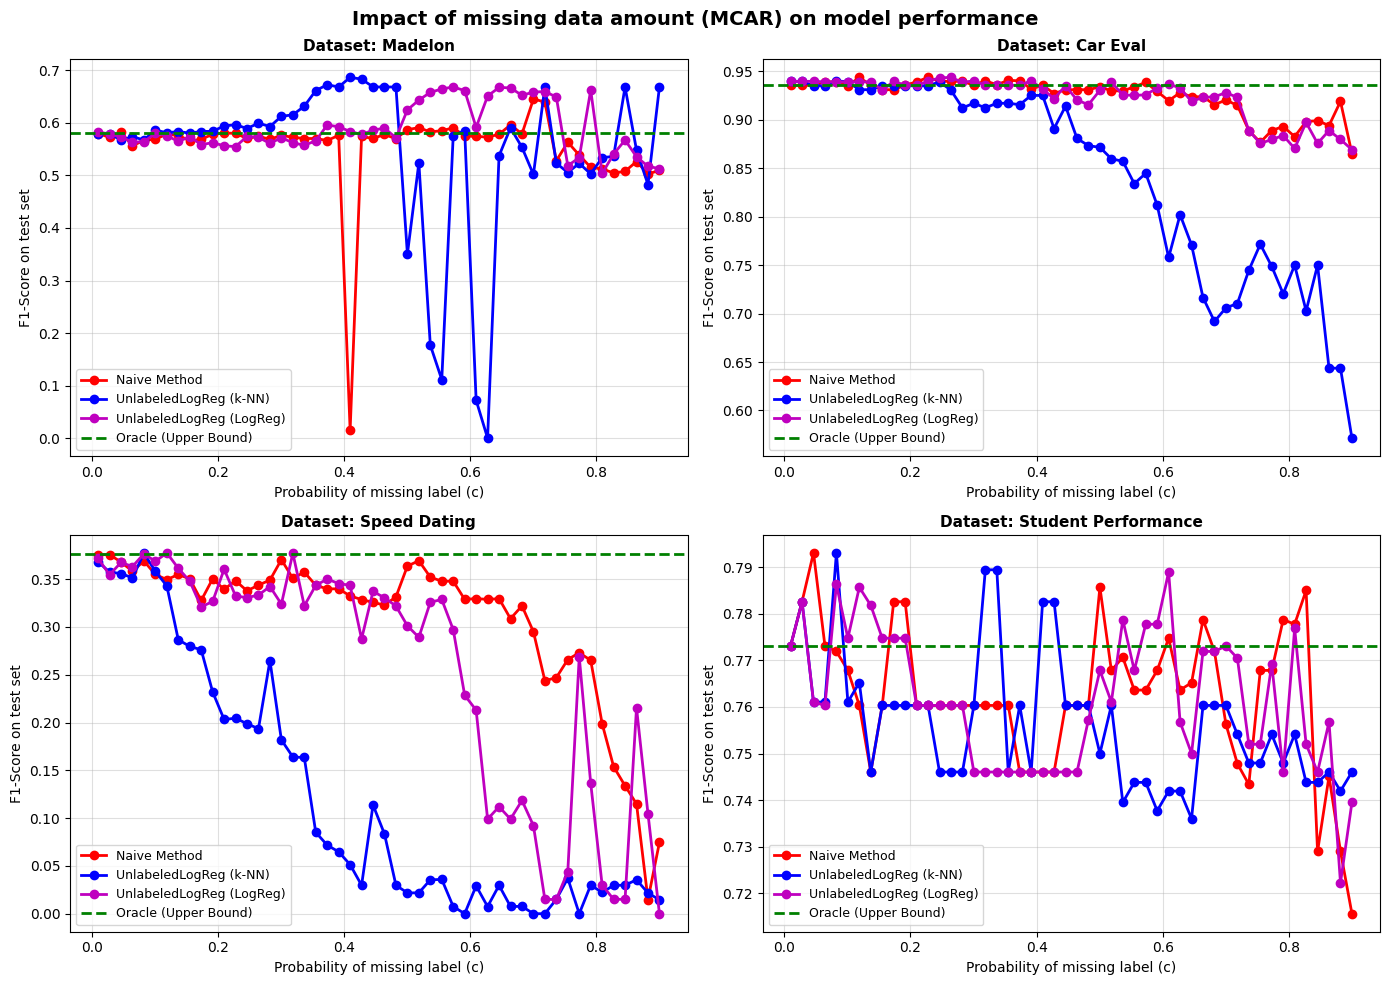

In [58]:
all_sensitivity_results = {}

for dataset_name in prepared_datasets.keys():
    data = prepared_datasets[dataset_name]
    
    X_tr = data['X_train']
    y_tr_true = data['y_train']
    X_val = data['X_valid']
    y_val = data['y_valid']
    X_ts = data['X_test']
    y_ts = data['y_test']
    
    c_values = np.linspace(0.01, 0.9, 50)  
    f1_naive = []
    f1_unlabeled_knn = []
    f1_unlabeled_logreg = []
    accuracy_naive = []
    accuracy_unlabeled_knn = []
    accuracy_unlabeled_logreg = []
    balanced_acc_naive = []
    balanced_acc_unlabeled_knn = []
    balanced_acc_unlabeled_logreg = []
    roc_auc_naive = []
    roc_auc_unlabeled_knn = []
    roc_auc_unlabeled_logreg = []
    
    print(f"Analyzing parameter 'c' for dataset: {dataset_name}...")
    
    # ORACLE MODEL
    oracle = FistaLogisticRegression(max_iter=1000, X_valid=X_val, y_valid=y_val)
    oracle.fit(X_tr, y_tr_true)
    oracle_score = evaluate_model(oracle, X_ts, y_ts)
    
    for c in c_values:
        y_tr_obs = apply_mcar(X_tr, y_tr_true, c=c)
        
        # NAIVE MODEL
        valid_mask = (y_tr_obs != -1)
        naive = FistaLogisticRegression(max_iter=1000, X_valid=X_val, y_valid=y_val)
        naive.fit(X_tr[valid_mask], y_tr_obs[valid_mask])
        naive_results = evaluate_model(naive, X_ts, y_ts)
        f1_naive.append(naive_results['F1-Score'])
        accuracy_naive.append(naive_results['Accuracy'])
        balanced_acc_naive.append(naive_results['Balanced Accuracy'])
        roc_auc_naive.append(naive_results['ROC AUC'])
        
        # UNLABELED MODEL with KNN Imputation
        unlabeled_knn = UnlabeledLogReg(fista_max_iter=1000, X_valid=X_val, y_valid=y_val, imputation_method='knn')
        unlabeled_knn.fit(X_tr, y_tr_obs)
        knn_results = evaluate_model(unlabeled_knn, X_ts, y_ts)
        f1_unlabeled_knn.append(knn_results['F1-Score'])
        accuracy_unlabeled_knn.append(knn_results['Accuracy'])
        balanced_acc_unlabeled_knn.append(knn_results['Balanced Accuracy'])
        roc_auc_unlabeled_knn.append(knn_results['ROC AUC'])
        
        # UNLABELED MODEL with LogReg Imputation
        unlabeled_logreg = UnlabeledLogReg(fista_max_iter=1000, X_valid=X_val, y_valid=y_val, imputation_method='logreg')
        unlabeled_logreg.fit(X_tr, y_tr_obs)
        logreg_results = evaluate_model(unlabeled_logreg, X_ts, y_ts)
        f1_unlabeled_logreg.append(logreg_results['F1-Score'])
        accuracy_unlabeled_logreg.append(logreg_results['Accuracy'])
        balanced_acc_unlabeled_logreg.append(logreg_results['Balanced Accuracy'])
        roc_auc_unlabeled_logreg.append(logreg_results['ROC AUC'])
    
    all_sensitivity_results[dataset_name] = {
        'c_values': c_values,
        'f1_naive': f1_naive,
        'f1_unlabeled_knn': f1_unlabeled_knn,
        'f1_unlabeled_logreg': f1_unlabeled_logreg,
        'accuracy_naive': accuracy_naive,
        'accuracy_unlabeled_knn': accuracy_unlabeled_knn,
        'accuracy_unlabeled_logreg': accuracy_unlabeled_logreg,
        'balanced_acc_naive': balanced_acc_naive,
        'balanced_acc_unlabeled_knn': balanced_acc_unlabeled_knn,
        'balanced_acc_unlabeled_logreg': balanced_acc_unlabeled_logreg,
        'roc_auc_naive': roc_auc_naive,
        'roc_auc_unlabeled_knn': roc_auc_unlabeled_knn,
        'roc_auc_unlabeled_logreg': roc_auc_unlabeled_logreg,
        'oracle_score': oracle_score
    }

# PLOTTING THE RESULTS FOR ALL DATASETS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dataset_name, results) in enumerate(all_sensitivity_results.items()):
    ax = axes[idx]
    ax.plot(results['c_values'], results['f1_naive'], 'ro-', linewidth=2, markersize=6, label='Naive Method')
    ax.plot(results['c_values'], results['f1_unlabeled_knn'], 'bo-', linewidth=2, markersize=6, label='UnlabeledLogReg (k-NN)')
    ax.plot(results['c_values'], results['f1_unlabeled_logreg'], 'mo-', linewidth=2, markersize=6, label='UnlabeledLogReg (LogReg)')
    ax.axhline(results['oracle_score']['F1-Score'], color='green', linestyle='--', linewidth=2, label='Oracle (Upper Bound)')
    
    ax.set_xlabel('Probability of missing label (c)', fontsize=10)
    ax.set_ylabel('F1-Score on test set', fontsize=10)
    ax.set_title(f'Dataset: {dataset_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('Impact of missing data amount (MCAR) on model performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
for dataset_name, results in all_sensitivity_results.items():
    # Create a DataFrame from the sensitivity analysis results
    df = pd.DataFrame({
        'c_values': results['c_values'],
        'Naive_F1': results['f1_naive'],
        'KNN_F1': results['f1_unlabeled_knn'],
        'LogReg_F1': results['f1_unlabeled_logreg'],
        'Naive_Accuracy': results['accuracy_naive'],
        'KNN_Accuracy': results['accuracy_unlabeled_knn'],
        'LogReg_Accuracy': results['accuracy_unlabeled_logreg']
    })
    print(f"\nResults for: {dataset_name}")
    display(df.round(4))


Results for: Madelon


,c_values,Naive_F1,KNN_F1,LogReg_F1,Naive_Accuracy,KNN_Accuracy,LogReg_Accuracy
0,0.0100,0.5797,0.5792,0.5824,0.5788,0.5808,0.5808
1,0.0282,0.5725,0.5797,0.5792,0.5750,0.5788,0.5808
2,0.0463,0.5819,0.5670,0.5731,0.5827,0.5712,0.5788
3,0.0645,0.5569,0.5737,0.5635,0.5654,0.5827,0.5769
4,0.0827,0.5664,0.5676,0.5641,0.5731,0.5692,0.5750
5,0.1008,0.5692,0.5865,0.5802,0.5750,0.5769,0.5769
6,0.1190,0.5785,0.5811,0.5758,0.5769,0.5731,0.5750
7,0.1371,0.5764,0.5836,0.5647,0.5788,0.5692,0.5731
8,0.1553,0.5659,0.5805,0.5737,0.5692,0.5692,0.5827
9,0.1735,0.5687,0.5836,0.5586,0.5712,0.5692,0.5654



Results for: Car Eval


,c_values,Naive_F1,KNN_F1,LogReg_F1,Naive_Accuracy,KNN_Accuracy,LogReg_Accuracy
0,0.0100,0.9356,0.9397,0.9397,0.9566,0.9595,0.9595
1,0.0282,0.9356,0.9397,0.9397,0.9566,0.9595,0.9595
2,0.0463,0.9356,0.9351,0.9397,0.9566,0.9566,0.9595
3,0.0645,0.9391,0.9351,0.9391,0.9595,0.9566,0.9595
4,0.0827,0.9391,0.9402,0.9391,0.9595,0.9595,0.9595
5,0.1008,0.9351,0.9391,0.9391,0.9566,0.9595,0.9595
6,0.1190,0.9437,0.9310,0.9391,0.9624,0.9538,0.9595
7,0.1371,0.9356,0.9310,0.9391,0.9566,0.9538,0.9595
8,0.1553,0.9310,0.9351,0.9304,0.9538,0.9566,0.9538
9,0.1735,0.9310,0.9351,0.9397,0.9538,0.9566,0.9595



Results for: Speed Dating


,c_values,Naive_F1,KNN_F1,LogReg_F1,Naive_Accuracy,KNN_Accuracy,LogReg_Accuracy
0,0.0100,0.3756,0.3682,0.3716,0.8473,0.8484,0.8467
1,0.0282,0.3756,0.3573,0.3545,0.8473,0.8562,0.8544
2,0.0463,0.3679,0.3558,0.3675,0.8544,0.8574,0.8562
3,0.0645,0.3583,0.3514,0.3632,0.8568,0.8568,0.8556
4,0.0827,0.3689,0.3772,0.3765,0.8449,0.8502,0.8479
5,0.1008,0.3548,0.3581,0.3686,0.8568,0.8502,0.8467
6,0.1190,0.3495,0.3429,0.3775,0.8556,0.8490,0.8484
7,0.1371,0.3548,0.2866,0.3613,0.8568,0.8574,0.8502
8,0.1553,0.3503,0.2796,0.3478,0.8473,0.8586,0.8479
9,0.1735,0.3277,0.2761,0.3209,0.8580,0.8592,0.8586



Results for: Student Performance


,c_values,Naive_F1,KNN_F1,LogReg_F1,Naive_Accuracy,KNN_Accuracy,LogReg_Accuracy
0,0.0100,0.7731,0.7731,0.7731,0.6582,0.6582,0.6582
1,0.0282,0.7826,0.7826,0.7826,0.6835,0.6835,0.6835
2,0.0463,0.7931,0.7611,0.7611,0.6962,0.6582,0.6582
3,0.0645,0.7731,0.7611,0.7603,0.6582,0.6582,0.6329
4,0.0827,0.7719,0.7931,0.7863,0.6709,0.6962,0.6835
5,0.1008,0.7679,0.7611,0.7748,0.6709,0.6582,0.6835
6,0.1190,0.7603,0.7652,0.7857,0.6329,0.6582,0.6962
7,0.1371,0.7460,0.7460,0.7818,0.5949,0.5949,0.6962
8,0.1553,0.7603,0.7603,0.7748,0.6329,0.6329,0.6835
9,0.1735,0.7826,0.7603,0.7748,0.6835,0.6329,0.6835


In [60]:
import os
import pickle

# Create results folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# Save all_experiment_results
with open('results/all_experiment_results.pkl', 'wb') as f:
    pickle.dump(all_experiment_results, f)

# Save all_sensitivity_results
with open('results/all_sensitivity_results.pkl', 'wb') as f:
    pickle.dump(all_sensitivity_results, f)

print("Results saved successfully!")
print(f"- all_experiment_results saved to: results/all_experiment_results.pkl")
print(f"- all_sensitivity_results saved to: results/all_sensitivity_results.pkl")

Results saved successfully!
- all_experiment_results saved to: results/all_experiment_results.pkl
- all_sensitivity_results saved to: results/all_sensitivity_results.pkl
